In [4]:
import analyze
import pandas as pd

In [5]:
df = analyze.load_dataset("./data/processed/feature_dataset.csv")
df

,sequential_execution_time,average_parallel_line_executions,parallel_execution_fraction,arrays_count,total_array_elements,total_array_size_bytes,avg_array_size_bytes,max_array_dimension,min_array_dimension,avg_array_dimension,...,parallelism_degree,is_power_of_two_threads,is_power_of_two_grid,potential_contention,oversubscription_factor,target_speedup,parallel_execution_time,program_name,launch_config,normalized_parallel_time
0,0.0,1.175000e+01,0.405172,2,2,8,4.0,1,1,1.0,...,36,0,0,1,12.0,0.247418,0.2033,acr1101,grid=[3]_threads=12,inf
1,0.0,1.175000e+01,0.405172,2,2,8,4.0,1,1,1.0,...,10,0,1,1,10.0,0.898214,0.0560,acr1101,grid=[1]_threads=10,inf
2,0.0,1.175000e+01,0.405172,2,2,8,4.0,1,1,1.0,...,17,0,1,1,17.0,0.182180,0.2761,acr1101,grid=[1]_threads=17,inf
3,0.0,1.175000e+01,0.405172,2,2,8,4.0,1,1,1.0,...,25,0,1,1,25.0,0.405318,0.1241,acr1101,grid=[1]_threads=25,inf
4,0.0,1.175000e+01,0.405172,2,2,8,4.0,1,1,1.0,...,22,0,1,1,22.0,0.455616,0.1104,acr1101,grid=[1]_threads=22,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,0.0,4.611686e+18,1.000000,4,4,16,4.0,1,1,1.0,...,15,0,1,1,15.0,1.000000,0.0002,cons1222,grid=[1]_threads=15,inf
30644,0.0,4.611686e+18,1.000000,4,4,16,4.0,1,1,1.0,...,18,0,1,1,18.0,1.000000,0.0002,cons1222,grid=[1]_threads=18,inf
30645,0.0,4.611686e+18,1.000000,4,4,16,4.0,1,1,1.0,...,80,0,1,1,20.0,0.250000,0.0008,cons1222,grid=[4]_threads=20,inf
30646,0.0,4.611686e+18,1.000000,4,4,16,4.0,1,1,1.0,...,81,0,0,1,27.0,0.285714,0.0007,cons1222,grid=[3]_threads=27,inf


In [15]:
target_col = "parallel_execution_time"
name_col = "program_name"

zeros_only = df.groupby(name_col)[target_col].apply(lambda s: (s < 0.01).all())
programs = zeros_only[zeros_only].index.tolist()

pd.Series(programs, name=name_col).to_csv("fast_programs.csv", index=False)

In [7]:
df[name_col].nunique()

716

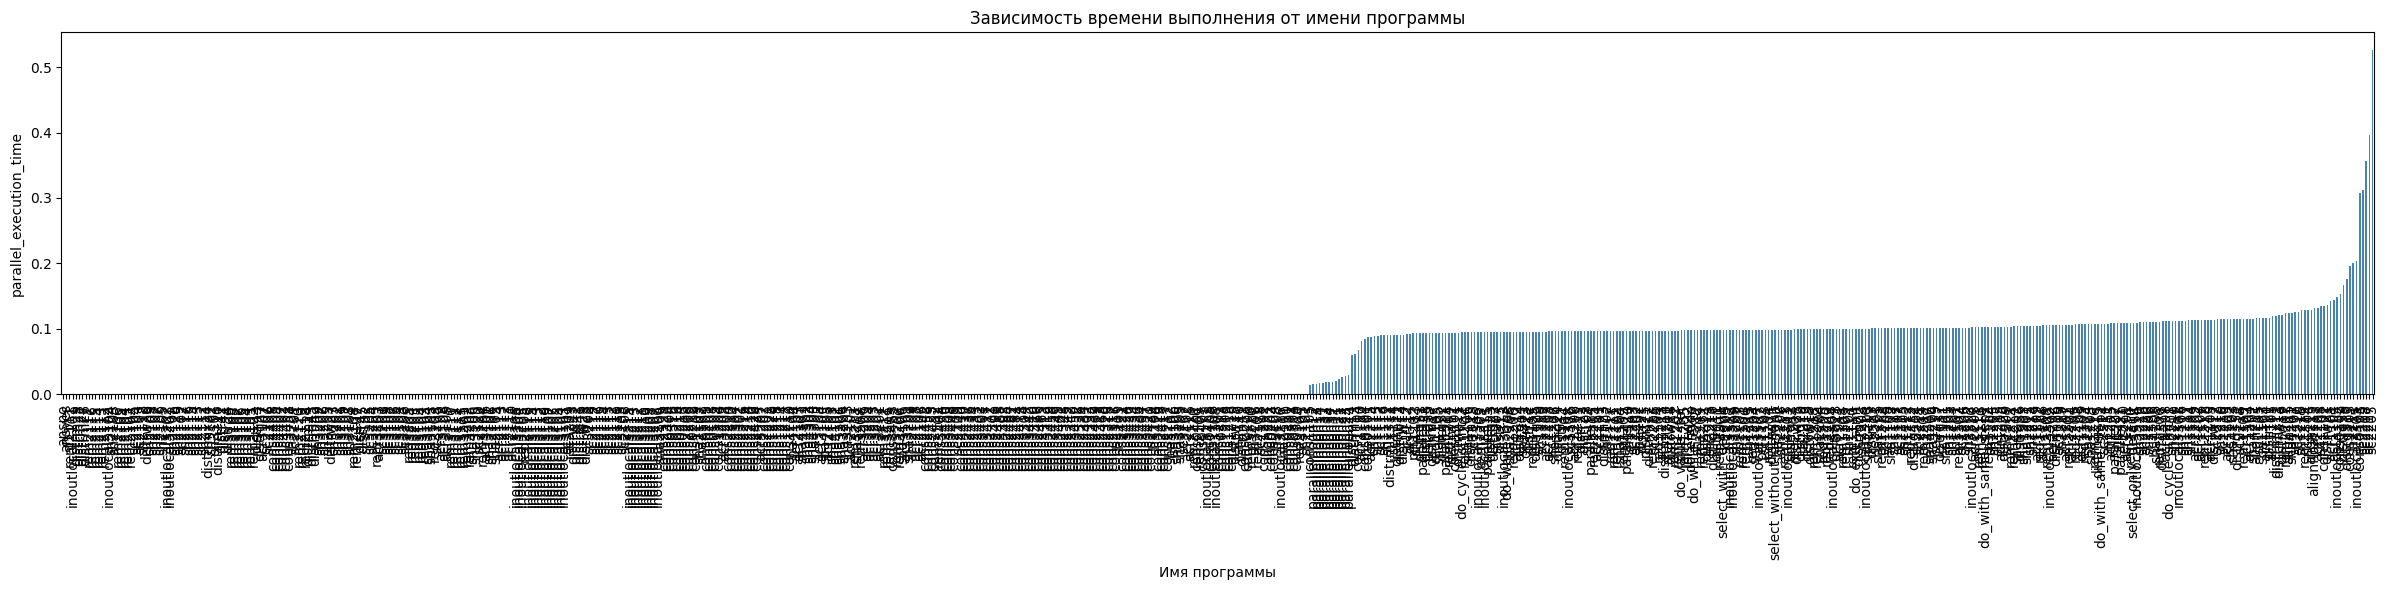

In [8]:
import matplotlib.pyplot as plt

program_time = (
    df.groupby(name_col)[target_col]
    .median()  # можно заменить на mean(), если нужен средний показатель
    .sort_values()
)

plt.figure(figsize=(24, 6))
program_time.plot(kind="bar", color="steelblue")
plt.title("Зависимость времени выполнения от имени программы")
plt.xlabel("Имя программы")
plt.ylabel(target_col)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()